In [168]:
import os
import json
import time
import threading
import psutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from memory_profiler import memory_usage
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import f1_score,  confusion_matrix

# loading processed dataset

In [2]:
with open('preprocessing_df_config.json', 'r') as f:
    config = json.load(f)

In [3]:
dataset_folder = 'dataset'
df = pd.read_parquet(os.path.join(dataset_folder, 'dataset_processed.parquet'))
df = df.drop(columns=config['columns_to_drop'])

# functions

In [5]:
# 1. Dynamic Custom Scorer Factory
def get_custom_scorer(contamination):
    """Generates a custom scoring function based on the dataset's contamination rate."""
    def custom_score(estimator, X, y):
        # The pipeline's decision_function will call the IsolationForest's decision_function
        anomaly_scores = estimator.decision_function(X)
        threshold = np.percentile(anomaly_scores, 100 * (1 - contamination))
        
        y_pred = (anomaly_scores <= threshold).astype(int)
        return f1_score(y, y_pred, pos_label=1, average='binary')
    
    return custom_score

In [130]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

def compute_roc(y_true, y_scores):
    """
    Computes ROC curve and AUC from the true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    """
    # Compute FPR, TPR, and thresholds using sklearn's roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc


def plot_roc_curve(fpr, tpr, roc_auc, title=None):
    """
    Plots the ROC curve with the given FPR, TPR and AUC.
    
    Parameters:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title if title else 'Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


def compute_pr_auc(y_true, y_scores):
    """
    Computes Precision-Recall curve and AUC from true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    """
    # Compute precision, recall, and thresholds using sklearn's precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve) for precision-recall
    pr_auc = auc(recall, precision)
    
    return precision, recall, pr_auc, thresholds


def plot_pr_curve(precision, recall, pr_auc, title=None):
    """
    Plots the Precision-Recall curve with the given precision, recall, and AUC.
    
    Parameters:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title if title else 'Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [6]:
def fit_pipeline_with_resources(pipeline, X_train, random_state=42):
    """Trains a pipeline while tracking memory, time, and CPU usage."""
    measurement = {}

    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    def train_model():
        pipeline.fit(X_train)

    try:
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        start_time = time.time()
        # Measure peak memory usage during the pipeline.fit execution
        train_memory = max(memory_usage((train_model,))) 
        training_time = time.time() - start_time

        stop_flag.set()
        cpu_thread.join()

        measurement['Memory Usage (MB)'] = train_memory
        measurement['Training Time (s)'] = training_time
        measurement['Peak CPU Usage (%)'] = max(cpu_usage) if cpu_usage else 0
        measurement['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        return measurement, pipeline

    except Exception as e:
        print(f"Error during pipeline training: {e}")
        stop_flag.set()
        return None, None

# 1st iteration of model
This iteration trains model on data with anomalies included and hopefully identify and isolate it with Isolation Forest technique

## train-test split

In [173]:
# Preparing features and truth labels
X = df.drop(['Label','anomaly','Destination Port'], axis=1)
y = df['anomaly']

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## defining model pipeline

In [174]:
def run_anomaly_detection_pipeline(X_train, X_test, y_train, y_test, cols_to_drop=None, param_grid=None):
    """
    Filters datasets, tunes hyperparameters, trains the final pipeline with resource 
    tracking, and extracts anomaly scores.
    """
    # Filter out feature-engineered columns if specified
    if cols_to_drop:
        X_train_filtered = X_train.drop(columns=cols_to_drop, errors='ignore')
        X_test_filtered = X_test.drop(columns=cols_to_drop, errors='ignore')
    else:
        X_train_filtered = X_train.copy()
        X_test_filtered = X_test.copy()

    # Calculate dynamic contamination rate based on training labels
    contamination = y_train.value_counts(normalize=True).get(1, 0.01)

    # Build the Pipeline
    # data scaling is actually useless with trees as they split the data randomly in between regardless of scale
    pipeline = Pipeline([
        # ('scaler', RobustScaler()),
        ('model', IsolationForest(random_state=42, n_jobs=-1))
    ])

    # Parameter grid (Note the 'model__' prefix required for pipeline steps)
    if param_grid is None:    
        param_grid = {
            'model__n_estimators': [100, 200, 300],
            'model__max_samples': [256, 512, 'auto'],
            'model__contamination': [0, contamination, 0.5],
            'model__max_features': [0.5, 0.7, 1.0]
        }

    # Setup RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=param_grid, 
        n_iter=27, 
        scoring=get_custom_scorer(contamination),
        cv=2, 
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    print("Tuning hyperparameters...")
    random_search.fit(X_train_filtered, y_train)

    print(f"\nBest Parameters: {random_search.best_params_}")
    print(f"Best Score: {random_search.best_score_}")

    # Configure a fresh pipeline with the best parameters for resource measurement
    best_pipeline = pipeline.set_params(**random_search.best_params_)

    print("\nTraining final model and measuring system resources...")
    measurements, final_pipeline = fit_pipeline_with_resources(best_pipeline, X_train_filtered)

    print("\nResource Measurements:")
    for key, value in measurements.items():
        print(f"  {key}: {value:.4f}")

    # Generate anomaly scores (-decision_function to make higher = more anomalous)
    anomaly_scores = -final_pipeline.decision_function(X_test_filtered)

    return final_pipeline, measurements, anomaly_scores

## training the model

In [175]:
if_pipeline_1, measurements_1, anomaly_scores_1 = run_anomaly_detection_pipeline(X_train, X_test, y_train, y_test)

Tuning hyperparameters...
Fitting 2 folds for each of 27 candidates, totalling 54 fits


c:\Users\Nathaniel\Projects\learning-sandbox\aim-capstone\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
16 fits failed out of a total of 54.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
16 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Nathaniel\Projects\learning-sandbox\aim-capstone\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Nathaniel\Projects\learning-sandbox\aim-capstone\.venv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Nathaniel\Projects\learning-sandbox


Best Parameters: {'model__n_estimators': 200, 'model__max_samples': 512, 'model__max_features': 1.0, 'model__contamination': np.float64(0.17689134273854704)}
Best Score: 0.35378241242630937

Training final model and measuring system resources...

Resource Measurements:
  Memory Usage (MB): 1709.7852
  Training Time (s): 12.0808
  Peak CPU Usage (%): 83.3000
  Average CPU Usage (%): 27.5495


In [176]:
import joblib

# Assuming 'final_pipeline' is the output from your run_anomaly_detection_pipeline function
pipeline_filename = 'if_iter1.joblib'

# Export the pipeline to a file
joblib.dump(if_pipeline_1, pipeline_filename)

print(f"Pipeline successfully saved to {pipeline_filename}")

Pipeline successfully saved to if_iter1.joblib


## testing model performance

### ROC and PR Curves

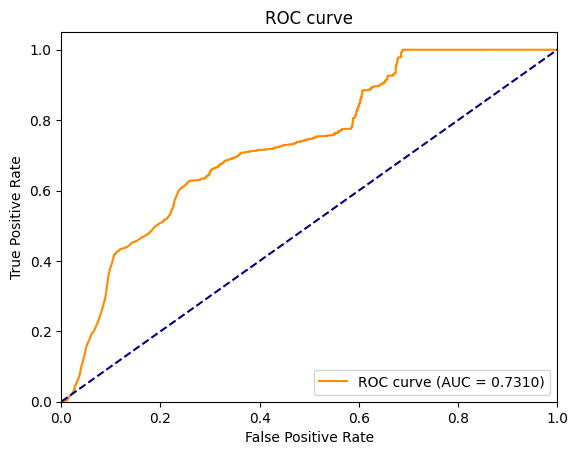

C:\Users\Nathaniel\AppData\Local\Temp\ipykernel_11308\3448066360.py:14: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * recall * precision / (recall + precision)


Best threshold:  -0.04127863334163134
Best F1-Score:  0.44462633890458464


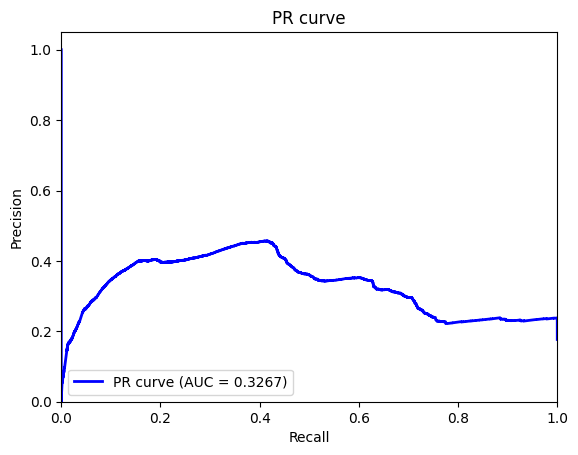

In [183]:
actual_anomaly = y_test

fpr, tpr, roc_auc = compute_roc(
    actual_anomaly,
    anomaly_scores_1)

# Plot ROC curve
plot_roc_curve(fpr, tpr, roc_auc, title='ROC curve')


precision, recall, pr_auc, threshold = compute_pr_auc(
    actual_anomaly,
    anomaly_scores_1)
f1_scores = 2 * recall * precision / (recall + precision)
print('Best threshold: ', threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])])
print('Best F1-Score: ', np.max(f1_scores[~np.isnan(f1_scores)]))
# Plot ROC curve
plot_pr_curve(precision, recall, pr_auc, title='PR curve')

### Recall vs Precision across threshold

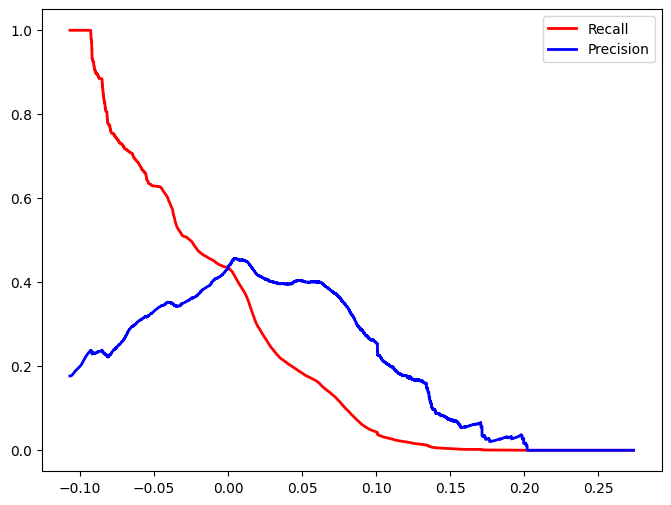

In [180]:
plt.figure(figsize=(8, 6))
plt.plot(threshold, recall[:-1], label='Recall', color='red', linewidth=2,)
plt.plot(threshold, precision[:-1], label='Precision', color='blue', linewidth=2,)
plt.legend()

### finding threshold and classification of anomalies

In [193]:
from sklearn.metrics import roc_curve, f1_score

# Compute ROC curve to determine optimal threshold for binary classification
fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores_1)

# optimal threshold by max f1 score
optimal_threshold = threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])]
print(f'Optimal Threshold: {optimal_threshold}')

# Classify anomalies
y_pred_if = (anomaly_scores_1 >= optimal_threshold).astype(int)

Optimal Threshold: -0.04127863334163134


### Classification Report

In [194]:
from sklearn.metrics import classification_report

# target_names allows you to label the output for better readability
print(classification_report(y_test, y_pred_if, target_names=['Normal', 'Anomaly'],))

              precision    recall  f1-score   support

      Normal       0.90      0.76      0.82    194361
     Anomaly       0.35      0.60      0.44     41770

    accuracy                           0.73    236131
   macro avg       0.63      0.68      0.63    236131
weighted avg       0.80      0.73      0.76    236131



### Confusion Matrix

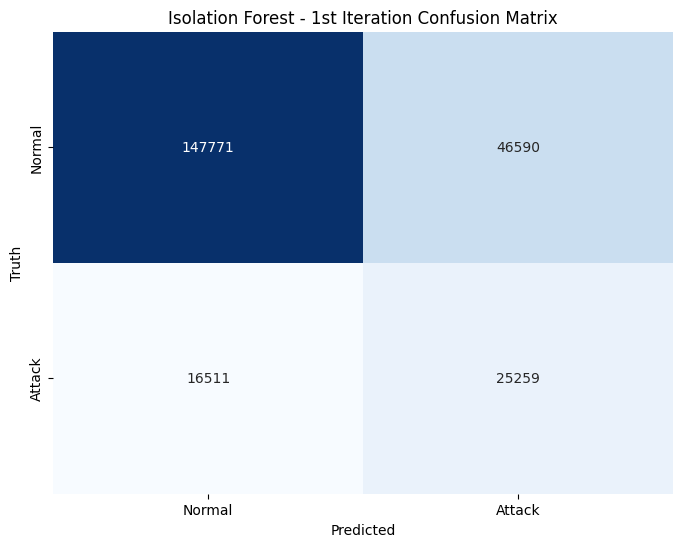

In [196]:
# Confusion Matrix for Binary Classification
cm_kmeans = confusion_matrix(y_test, y_pred_if)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Isolation Forest - 1st Iteration Confusion Matrix')
plt.show()

# 2nd iteration
This iteration trains model on data without anomalies included. Predicted downside of this model would be predicting some anomalies as false positives due to model trying hard to find anomalies in a clean dataset. But the upside could be a more confident prediction of anomaly as the model would first encounter anomalous data on testing 

## train-test split

In [197]:
# Preparing features and truth labels
X = df.drop(['Label','anomaly','Destination Port'], axis=1)
y = df['anomaly']

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Remove anomalies in the training dataset
X_train = X_train[y_train == 0]
y_train = y_train[y_train == 0]

In [198]:
def run_anomaly_detection_pipeline(X_train, X_test, y_train, y_test, cols_to_drop=None):
    """
    Filters datasets, tunes hyperparameters, trains the final pipeline with resource 
    tracking, and extracts anomaly scores.
    """
    # Filter out feature-engineered columns if specified
    if cols_to_drop:
        X_train_filtered = X_train.drop(columns=cols_to_drop, errors='ignore')
        X_test_filtered = X_test.drop(columns=cols_to_drop, errors='ignore')
    else:
        X_train_filtered = X_train.copy()
        X_test_filtered = X_test.copy()

    # Calculate dynamic contamination rate based on training labels
    contamination = y_train.value_counts(normalize=True).get(1, 0.01)

    # Build the Pipeline
    pipeline = Pipeline([
        # ('scaler', RobustScaler()),
        ('model', IsolationForest(random_state=42, n_jobs=-1))
    ])

    # Parameter grid (Note the 'model__' prefix required for pipeline steps)
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_samples': [256, 512, 'auto'],
        'model__contamination': [0, contamination, 0.5],
        'model__max_features': [0.5, 0.7, 1.0]
    }

    # Setup RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=param_grid, 
        n_iter=27, 
        scoring='average_precision',
        cv=2, 
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    print("Tuning hyperparameters...")
    random_search.fit(X_train_filtered, y_train)

    print(f"\nBest Parameters: {random_search.best_params_}")
    print(f"Best Score: {random_search.best_score_}")

    # Configure a fresh pipeline with the best parameters for resource measurement
    best_pipeline = pipeline.set_params(**random_search.best_params_)

    print("\nTraining final model and measuring system resources...")
    measurements, final_pipeline = fit_pipeline_with_resources(best_pipeline, X_train_filtered)

    print("\nResource Measurements:")
    for key, value in measurements.items():
        print(f"  {key}: {value:.4f}")

    # Generate anomaly scores (-decision_function to make higher = more anomalous)
    anomaly_scores = -final_pipeline.decision_function(X_test_filtered)
    # anomaly_scores = -final_pipeline.score_samples(X_test_filtered)

    return final_pipeline, measurements, anomaly_scores

## training the model

In [199]:
if_pipeline_2, measurements_2, anomaly_scores_2 = run_anomaly_detection_pipeline(X_train, X_test, y_train, y_test)

Tuning hyperparameters...
Fitting 2 folds for each of 27 candidates, totalling 54 fits


c:\Users\Nathaniel\Projects\learning-sandbox\aim-capstone\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
16 fits failed out of a total of 54.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
16 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Nathaniel\Projects\learning-sandbox\aim-capstone\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Nathaniel\Projects\learning-sandbox\aim-capstone\.venv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Nathaniel\Projects\learning-sandbox


Best Parameters: {'model__n_estimators': 100, 'model__max_samples': 512, 'model__max_features': 0.5, 'model__contamination': 0.01}
Best Score: 0.0

Training final model and measuring system resources...

Resource Measurements:
  Memory Usage (MB): 3303.8672
  Training Time (s): 9.2479
  Peak CPU Usage (%): 88.3000
  Average CPU Usage (%): 34.7605


In [200]:
import joblib

# Assuming 'final_pipeline' is the output from your run_anomaly_detection_pipeline function
pipeline_filename = 'if_iter2.joblib'

# Export the pipeline to a file
joblib.dump(if_pipeline_2, pipeline_filename)

print(f"Pipeline successfully saved to {pipeline_filename}")

Pipeline successfully saved to if_iter2.joblib


## testing model performance

### ROC and PR Curves

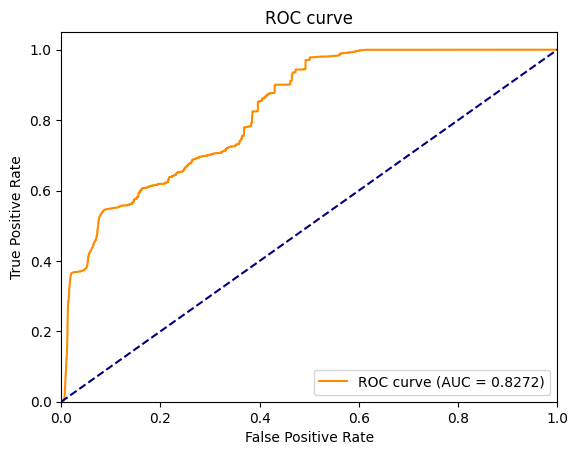

C:\Users\Nathaniel\AppData\Local\Temp\ipykernel_11308\122186069.py:14: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * recall * precision / (recall + precision)


Best threshold:  -0.13010351943467802
Best F1-Score:  0.5605273671594088


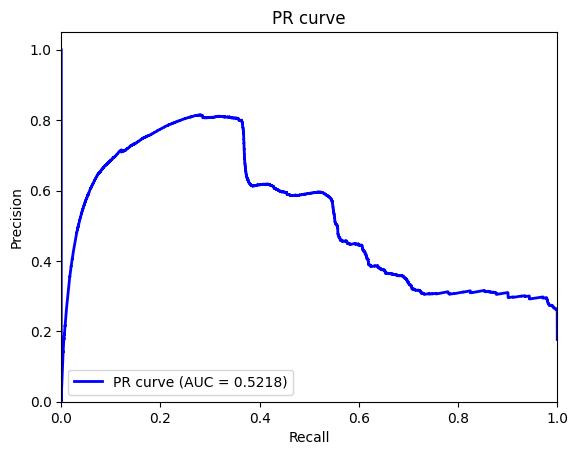

In [201]:
actual_anomaly = y_test

fpr, tpr, roc_auc = compute_roc(
    actual_anomaly,
    anomaly_scores_2)

# Plot ROC curve
plot_roc_curve(fpr, tpr, roc_auc, title='ROC curve')


precision, recall, pr_auc, threshold = compute_pr_auc(
    actual_anomaly,
    anomaly_scores_2)
f1_scores = 2 * recall * precision / (recall + precision)
print('Best threshold: ', threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])])
print('Best F1-Score: ', np.max(f1_scores[~np.isnan(f1_scores)]))
# Plot ROC curve
plot_pr_curve(precision, recall, pr_auc, title='PR curve')

### Recall vs Precision across threshold

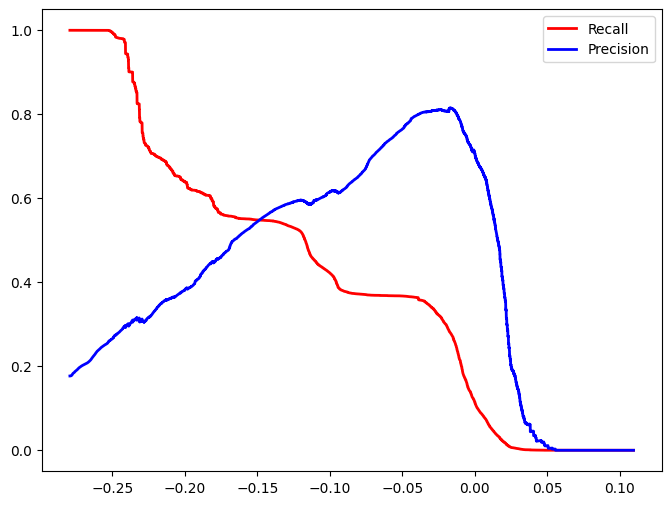

In [202]:
plt.figure(figsize=(8, 6))
plt.plot(threshold, recall[:-1], label='Recall', color='red', linewidth=2,)
plt.plot(threshold, precision[:-1], label='Precision', color='blue', linewidth=2,)
plt.legend()

### finding threshold and classification of anomalies

In [204]:
from sklearn.metrics import roc_curve, f1_score

# Compute ROC curve to determine optimal threshold for binary classification
fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores_2)

# optimal threshold by max f1 score
optimal_threshold = threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])]
print(f'Optimal Threshold: {optimal_threshold}')

# Classify anomalies
y_pred_if = (anomaly_scores_2 >= optimal_threshold).astype(int)

Optimal Threshold: -0.13010351943467802


### Classification Report

In [205]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_if, target_names=['Normal', 'Anomaly'],))

              precision    recall  f1-score   support

      Normal       0.90      0.92      0.91    194361
     Anomaly       0.59      0.54      0.56     41770

    accuracy                           0.85    236131
   macro avg       0.74      0.73      0.74    236131
weighted avg       0.85      0.85      0.85    236131



### Confusion Matrix

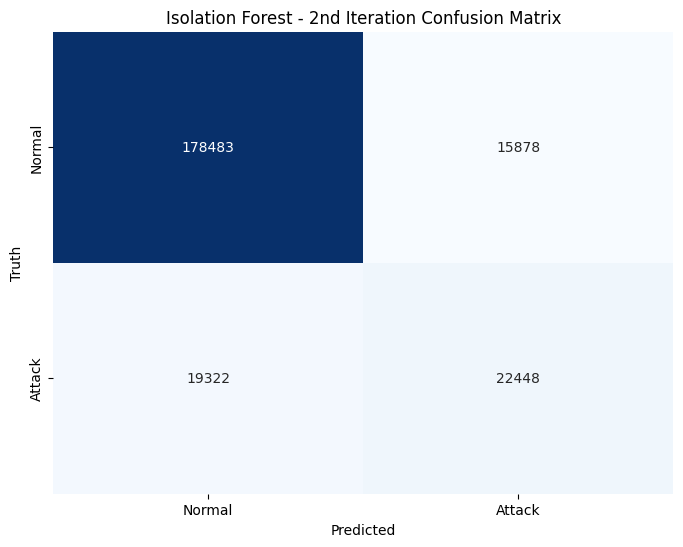

In [206]:
# Confusion Matrix for Binary Classification
cm_kmeans = confusion_matrix(y_test, y_pred_if)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Isolation Forest - 2nd Iteration Confusion Matrix')
plt.show()

# Analysis

## Issue with initial drop on PR Curve

The Dip and Rise at Low Recall

The most striking feature is that your precision starts near zero, spikes briefly, drops, and then begins to climb until it peaks around 0.4 recall on 1st iteration and 0.8 on 2nd.

Precision is calculated as TP/(TP+FP​). A low precision at low recall redion means that the instances your model is normally most certain are anomalies (those with the highest anomaly scores) are actually False Positives.

In an Isolation Forest, anomalies are points that are "easier" to isolate (shorter path lengths). If your curve looks like this, it suggests that your model is isolating normal data points much faster than the actual anomalies. This often happens if the "normal" data is sparse or if the anomalies are clustered in a way that makes them look "normal" to the tree structures.

This event may be due to nature of network traffic itself. Outliers may be tagged as anomalies/intrusions but are actually just bottlenecks in the system, slowing down the system

## Comparing 2 iterations

|Metric|Iteration 1 (Mixed Train)|Iteration 2 (Clean Train)|Change|
|---|---|---|---|
|Overall Accuracy|0.73|0.85|+12%|
|Normal Recall|0.76|0.92|+16%|
|Anomaly Precision|0.35|0.59|+24%|
|Anomaly F1-Score|0.44|0.56|+12%|

By just looking at the table above, we can clearly say that Iteration 2 was the winner. But why is that?
- Prevented familiarization of model to anomalies

    Isolation forest works by isolating points. In iteration 1, anomalous data are present during training and model might learn these as a normal variation of clusters

- Clear boundary

    In iteration 2, model only saw clean data during training. It built a tight figure on what data generally looks like. And when we introduced the test data with anomalies, model was foreign with anomalous data and scored it high 

